<a href="https://www.kaggle.com/code/sonawanelalitsunil/foodpanda-review-ml-50-92?scriptVersionId=260450179" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/foodpanda-review-dataset/Foodpanda Analysis Dataset.csv


## Title:
📊 Foodpanda Review Dataset

## Description:
This dataset contains customer reviews and ratings collected from the Foodpanda platform. It provides insights into customer experiences, including food quality, delivery service, pricing, and overall satisfaction. The dataset can be used for sentiment analysis, text classification, customer satisfaction modeling, and business intelligence tasks. Researchers and analysts can explore key patterns in user feedback to identify factors influencing customer loyalty, detect areas needing improvement, and develop predictive models for customer sentiment.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/foodpanda-review-dataset/Foodpanda Analysis Dataset.csv")

In [3]:
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


In [4]:
df.tail()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
5995,C6849,Male,Adult,Multan,11/25/2024,O10849,8/22/2025,Pizza Hut,Burger,Italian,4,875.71,Cash,28,11/29/2024,166,Active,5,12/30/2024,Cancelled
5996,C3787,Female,Adult,Islamabad,1/28/2025,O7787,8/22/2025,KFC,Pizza,Italian,5,1118.26,Cash,12,6/8/2025,193,Inactive,3,2/9/2025,Delayed
5997,C2841,Other,Teenager,Islamabad,10/19/2023,O6841,8/22/2025,KFC,Sandwich,Italian,4,1005.83,Card,31,12/30/2024,278,Active,4,3/23/2025,Cancelled
5998,C1624,Male,Adult,Islamabad,6/17/2024,O5624,8/22/2025,KFC,Fries,Fast Food,4,1226.10,Card,37,12/27/2024,55,Inactive,2,3/15/2025,Delivered
5999,C2068,Female,Adult,Multan,3/15/2025,O6068,8/22/2025,Burger King,Fries,Fast Food,3,1131.27,Card,2,6/13/2025,41,Inactive,1,7/15/2025,Delayed


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

In [6]:
df.describe()

,quantity,price,order_frequency,loyalty_points,rating
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2.991667,800.524880,25.304667,250.173667,2.996833
std,1.414778,404.855029,14.358930,144.608478,1.406113
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,441.997500,13.000000,125.000000,2.000000
50%,3.000000,806.460000,25.000000,249.500000,3.000000
75%,4.000000,1149.737500,37.000000,378.000000,4.000000
max,5.000000,1499.950000,50.000000,500.000000,5.000000


In [7]:
df.dtypes

customer_id         object
gender              object
age                 object
city                object
signup_date         object
order_id            object
order_date          object
restaurant_name     object
dish_name           object
category            object
quantity             int64
price              float64
payment_method      object
order_frequency      int64
last_order_date     object
loyalty_points       int64
churned             object
rating               int64
rating_date         object
delivery_status     object
dtype: object

In [8]:
df.shape

(6000, 20)

In [9]:
df.isnull().sum()

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'signup_date', 'order_id',
       'order_date', 'restaurant_name', 'dish_name', 'category', 'quantity',
       'price', 'payment_method', 'order_frequency', 'last_order_date',
       'loyalty_points', 'churned', 'rating', 'rating_date',
       'delivery_status'],
      dtype='object')

## Data visualizations

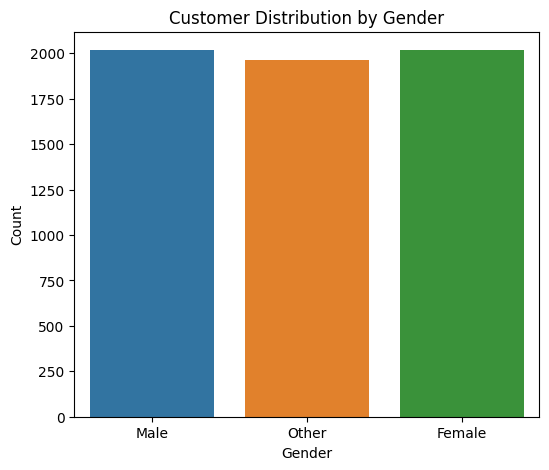

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="gender")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

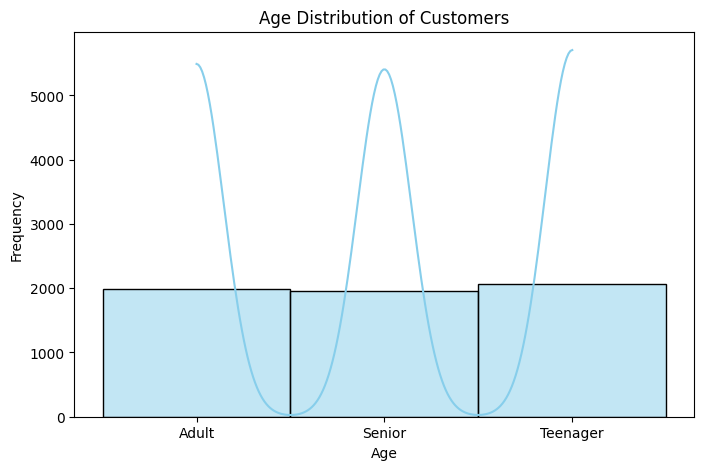

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


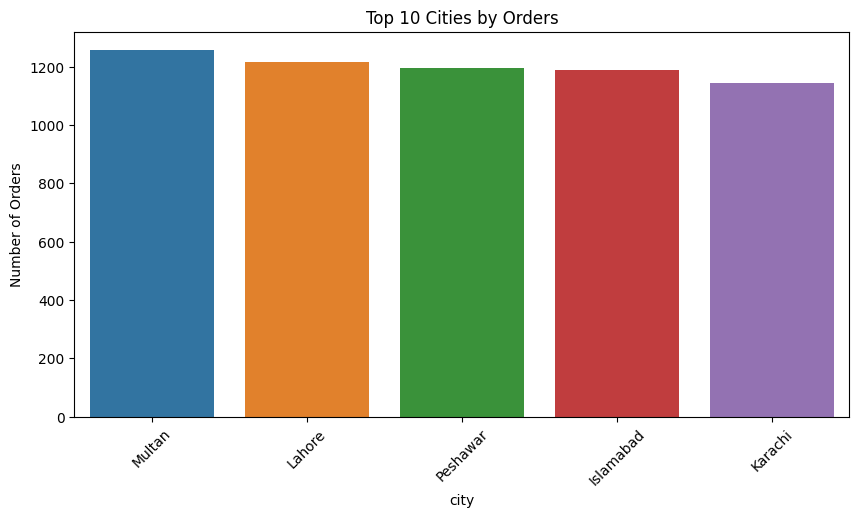

In [14]:
plt.figure(figsize=(10,5))
city_counts = df['city'].value_counts().head(10)
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.title("Top 10 Cities by Orders")
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.show()

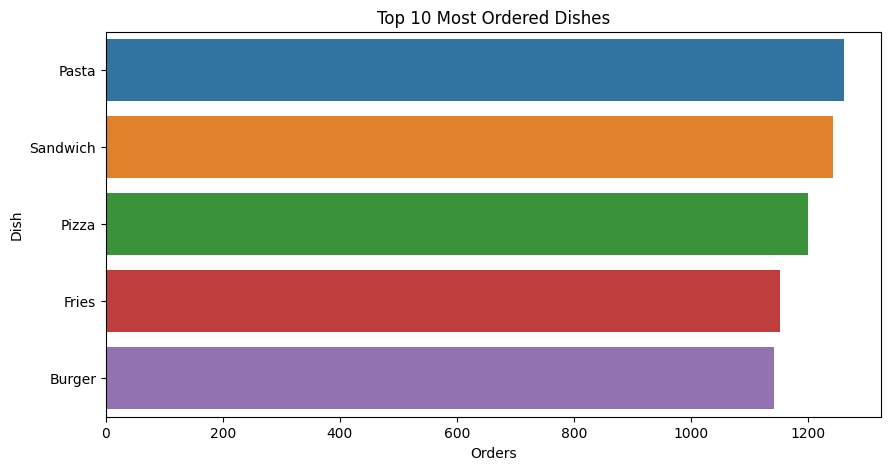

In [15]:
plt.figure(figsize=(10,5))
dish_counts = df['dish_name'].value_counts().head(10)
sns.barplot(x=dish_counts.values, y=dish_counts.index)
plt.title("Top 10 Most Ordered Dishes")
plt.xlabel("Orders")
plt.ylabel("Dish")
plt.show()


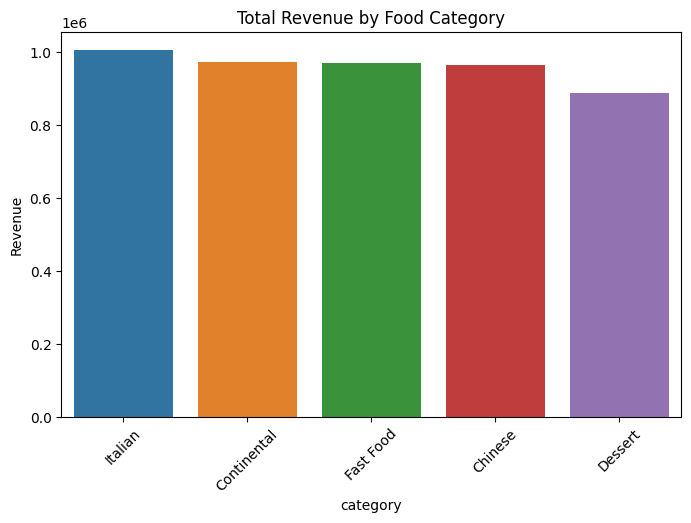

In [16]:
plt.figure(figsize=(8,5))
category_revenue = df.groupby("category")['price'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.title("Total Revenue by Food Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

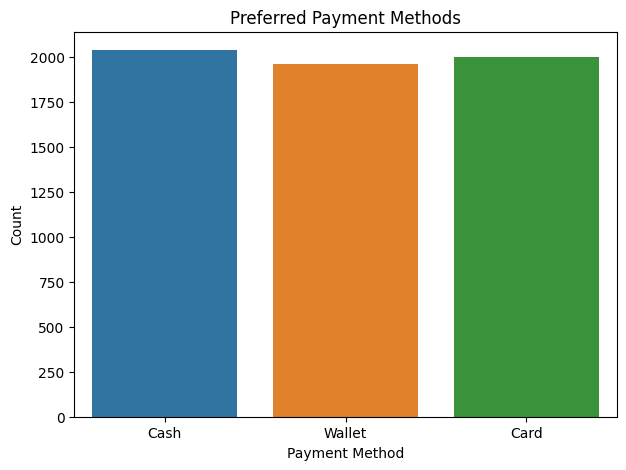

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="payment_method")
plt.title("Preferred Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

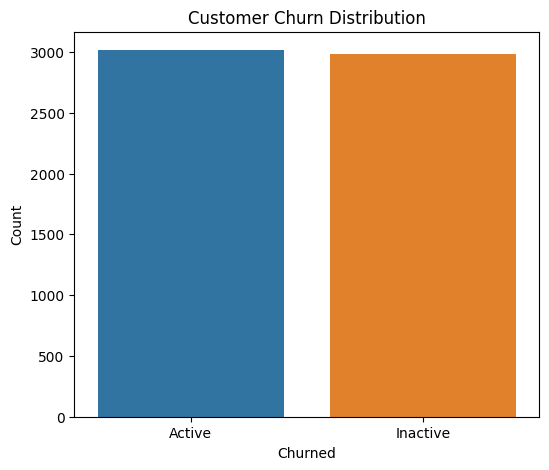

In [18]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="churned")
plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Count")
plt.show()


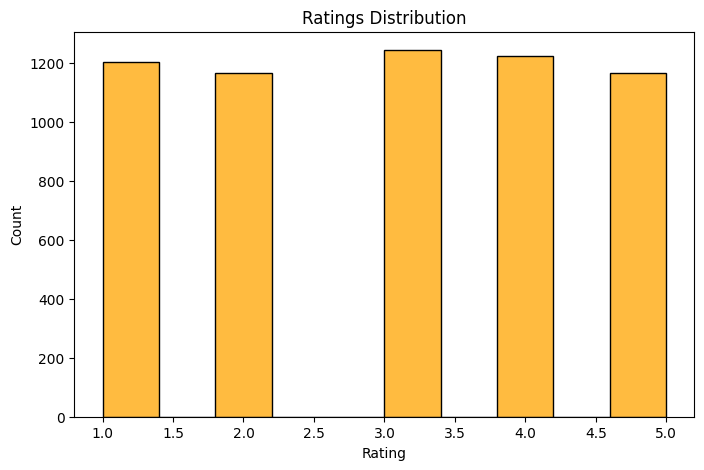

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=10, kde=False, color="orange")
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

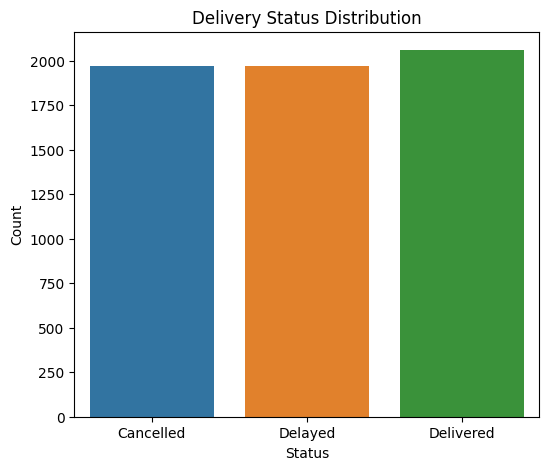

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="delivery_status")
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

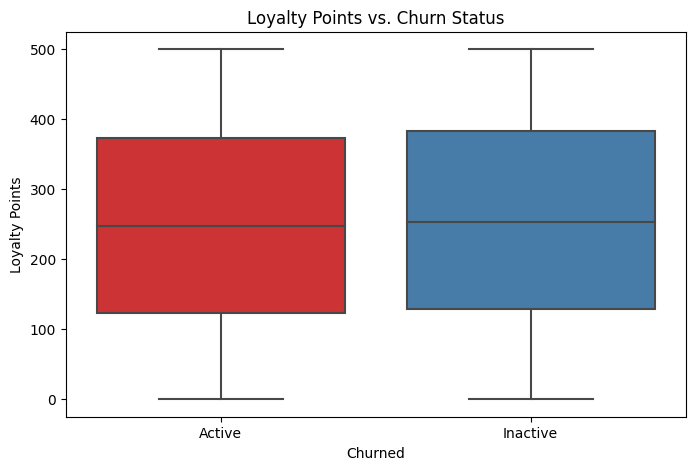

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="churned", y="loyalty_points", palette="Set1")
plt.title("Loyalty Points vs. Churn Status")
plt.xlabel("Churned")
plt.ylabel("Loyalty Points")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

                 Model  Accuracy (%)
0  Logistic Regression         50.42
1        Decision Tree         51.25
2        Random Forest         51.33
3    Gradient Boosting         49.67
4                  KNN         50.92
5                  SVM         47.83
6          Naive Bayes         50.42
7              XGBoost         49.75


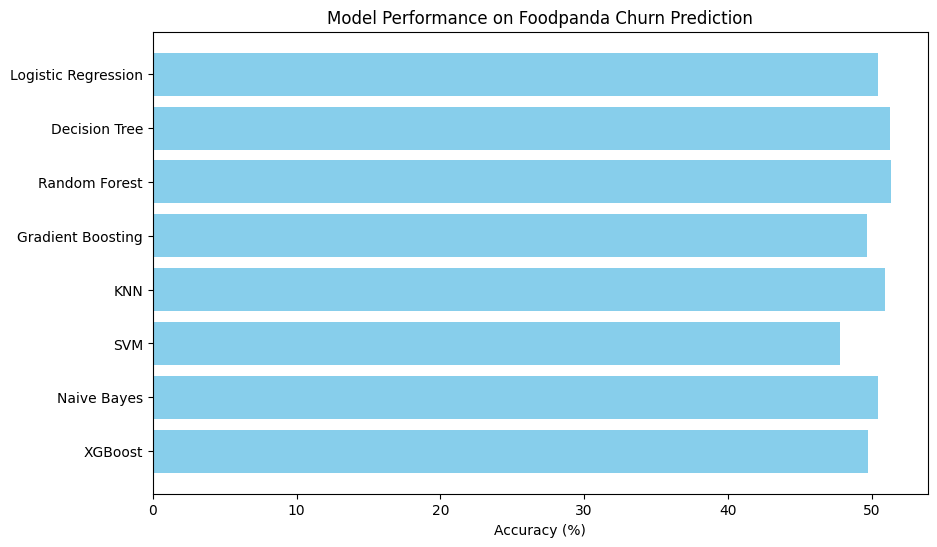

In [23]:
df = df.copy()

target = "churned"   # predicting churn
df = df.dropna(subset=[target])  # drop rows without churn info

categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=[target])
y = df[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append((name, round(acc, 2)))


results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"])
print(results_df)



plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["Accuracy (%)"], color="skyblue")
plt.xlabel("Accuracy (%)")
plt.title("Model Performance on Foodpanda Churn Prediction")
plt.gca().invert_yaxis()
plt.show()

## Thank you..pls upvote!!!!